# SEPNet Evaluation — Kvasir-SEG & LDPolypDB
Loads pretrained **SEPNet** (Wang et al., IEEE TCSVT 2024) weights and computes Dice / mIoU on Kvasir-SEG and LDPolypDB.
All dataset and weight paths are discovered dynamically from `/kaggle/input/` — **no hardcoded paths**.

**Before running:** attach the Kvasir-SEG dataset, the LDPolypDB dataset, and a Kaggle Dataset/notebook output containing the `.pth` SEPNet checkpoint as inputs, and enable a GPU accelerator.

In [2]:
# Example for running a PyTorch repo in Kaggle
!pip install -r requirements.txt
# Or install specific missing dependencies:
!pip install timm==0.4.12 opencv-python scikit-learn

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 13.2 MB/s eta 0:00:00
  Attempting uninstall: timm
    Found existing installation: timm 1.0.26
    Uninstalling timm-1.0.26:
      Successfully uninstalled timm-1.0.26


In [3]:
# ==== Cell 1: Environment Setup & GPU Check ====
import os, sys, subprocess, warnings
warnings.filterwarnings("ignore")

def pip_install(pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)

try:
    import timm
    from timm.models.layers import DropPath  # noqa: F401 - SEPNet backbone needs the old timm.models.layers API
except Exception:
    pip_install(["timm==0.5.4"])
    import timm

import torch
print(f"PyTorch: {torch.__version__} | timm: {timm.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    DEVICE = torch.device("cuda")
else:
    print("WARNING: No GPU detected — enable a GPU accelerator in Kaggle settings for reasonable runtime.")
    DEVICE = torch.device("cpu")


PyTorch: 2.10.0+cu128 | timm: 0.4.12
CUDA available: True
GPU: Tesla T4


In [4]:
# ==== Cell 2: Repository Cloning & Imports ====
REPO_DIR = "/kaggle/working/SEPNet"
if not os.path.isdir(os.path.join(REPO_DIR, ".git")):
    subprocess.run(["git", "clone", "--depth", "1",
                     "https://github.com/wangtong627/SEPNet.git", REPO_DIR], check=True)
else:
    print("SEPNet repo already present, skipping clone.")

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

import glob
from pathlib import Path

import numpy as np
import cv2
from PIL import Image
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader

from lib.model_for_eval import SEPNet_EvalModel  # noqa: E402

print("SEPNet repo imports OK.")


Cloning into '/kaggle/working/SEPNet'...


SEPNet repo imports OK.


In [5]:
# ==== Cell 3: Dataset Discovery & PyTorch Dataset/DataLoader ====
from pathlib import Path

KAGGLE_INPUT = Path("/kaggle/input")

DATASETS = {
    "Kvasir": ["kvasir", "kvasirseg", "kvasir_seg"],
    "CVC-ClinicDB": ["cvc", "clinicdb", "cvcclinicdb"],
}

def find_dataset(keywords):
    IMAGE_DIR_NAMES = {"images", "image", "img", "imgs", "images_png", "frame", "frames", "raw", "jpg", "png"}
    MASK_DIR_NAMES = {"masks", "mask", "gt", "gts", "ground_truth", "groundtruth", "label", "labels", "annotations", "annotation", "masks_png", "target"}
    
    img_dir, mask_dir = None, None
    for p in KAGGLE_INPUT.rglob("*"):
        if p.is_dir():
            folder_name = p.name.lower()
            if any(kw in str(p).lower() for kw in keywords):
                if folder_name in IMAGE_DIR_NAMES and img_dir is None:
                    img_dir = p
                elif folder_name in MASK_DIR_NAMES and mask_dir is None:
                    mask_dir = p
                    
    if img_dir and mask_dir:
        img_files = sorted([f for f in img_dir.iterdir() if f.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]])
        mask_files = sorted([f for f in mask_dir.iterdir() if f.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]])
        pairs = list(zip(img_files, mask_files))
        return pairs, (img_dir, mask_dir)
    return [], (None, None)
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
IMAGE_DIR_NAMES = {
    "images", "image", "img", "imgs", "images_png", 
    "frame", "frames", "raw", "jpg", "png"
}
MASK_DIR_NAMES = {
    "masks", "mask", "gt", "gts", "ground_truth", 
    "groundtruth", "label", "labels", "annotations", 
    "annotation", "masks_png", "target"
}
KAGGLE_INPUT = Path("/kaggle/input")


def discover_image_mask_dirs(base: Path):
    """Walk `base` and return every (images_dir, masks_dir) pair found by folder-name convention."""
    pairs = []
    for root, dirs, _files in os.walk(base):
        root_p = Path(root)
        for d in dirs:
            if d.lower() in IMAGE_DIR_NAMES:
                img_dir = root_p / d
                mask_dir = None
                for sib in root_p.iterdir():
                    if sib.is_dir() and sib.name.lower() in MASK_DIR_NAMES:
                        mask_dir = sib
                        break
                if mask_dir is not None:
                    pairs.append((img_dir, mask_dir))
    return pairs


def pair_files(img_dir: Path, mask_dir: Path):
    """Pair image/mask files by filename stem, ignoring extension differences."""
    imgs = {p.stem: p for p in img_dir.iterdir() if p.suffix.lower() in IMG_EXTS}
    masks = {p.stem: p for p in mask_dir.iterdir() if p.suffix.lower() in IMG_EXTS}
    stems = sorted(set(imgs) & set(masks))
    return [(imgs[s], masks[s]) for s in stems]


def find_dataset(keywords):
    """Return the largest (img, mask) pair-list among discovered dirs whose path matches any keyword."""
    all_pairs = discover_image_mask_dirs(KAGGLE_INPUT)
    best_pairs, best_dirs = [], None
    for img_dir, mask_dir in all_pairs:
        path_lc = str(img_dir).lower()
        if any(k in path_lc for k in keywords):
            fp = pair_files(img_dir, mask_dir)
            if len(fp) > len(best_pairs):
                best_pairs, best_dirs = fp, (img_dir, mask_dir)
    return best_pairs, best_dirs



TEST_SIZE = 352


class PolypDataset(Dataset):
    def __init__(self, pairs, transform=None):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image = image.resize((TEST_SIZE, TEST_SIZE), Image.BILINEAR)
        mask = mask.resize((TEST_SIZE, TEST_SIZE), Image.NEAREST)

        # Image preprocessing matching ImageNet standards used in SEPNet
        transform_img = T.Compose([
            T.Resize((352, 352)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

        transform_mask = T.Compose([
            T.Resize((352, 352)),
            T.ToTensor(),
        ])

        img_tensor = transform_img(image)
        mask_tensor = torch.from_numpy(np.array(mask) / 255.0).float().unsqueeze(0)

        return img_tensor, mask_tensor, img_path.stem

# Build DataLoaders
loaders = {}
for ds_name, keywords in DATASETS.items():
    pairs, ddirs = find_dataset(keywords)
    if pairs:
        print(f"[{ds_name}] found {len(pairs)} image/mask pairs at: {ddirs[0]}  |  {ddirs[1]}")
        ds = PolypDataset(pairs)
        loaders[ds_name] = DataLoader(ds, batch_size=1, shuffle=False, num_workers=2)
    else:
        print(f"[{ds_name}] NOT FOUND under /kaggle/input — check folder keywords or attach dataset.")

[Kvasir] found 1000 image/mask pairs at: /kaggle/input/datasets/varshasrao/kvasirseg-og/Kvasir-SEG/images  |  /kaggle/input/datasets/varshasrao/kvasirseg-og/Kvasir-SEG/masks
[CVC-ClinicDB] NOT FOUND under /kaggle/input — check folder keywords or attach dataset.


In [8]:
# ==== Cell 4: SEPNet Model Initialization & Pretrained Weights Loading ====
BACKBONE_NAME = "pvt-v2-b2"
MID_CHANNELS = 64

model = SEPNet_EvalModel(
    backbone_name=BACKBONE_NAME,
    pretrained_backbone_path=None,
    mid_channels=MID_CHANNELS,
    rf_reduction_scale=4,
    rf_se_channel_reduction=16,
    df_channel_reduction=[4, 4],
    sc_hidden_scale=32,
    sc_ksize=[3, 3, 3],
    sc_gas_ksize=1,
    sc_gas_ksize_scale=[15, 15, 15],
    sc_middle_channle_scale=2,
).to(DEVICE)

# Auto-discover weights under /kaggle/input
weight_candidates = list(KAGGLE_INPUT.rglob("*.pth")) + list(KAGGLE_INPUT.rglob("*.pt"))
if not weight_candidates:
    raise FileNotFoundError("No weight checkpoint (.pth or .pt) found under /kaggle/input")

weight_path = weight_candidates[0]
print(f"Loading weights from: {weight_path}")

checkpoint = torch.load(weight_path, map_location=DEVICE)

# Extract inner state dict if wrapped in metadata
if isinstance(checkpoint, dict):
    if "model_state_dict" in checkpoint:
        checkpoint = checkpoint["model_state_dict"]
    else:
        for key in ["state_dict", "model", "net", "state_dict_ema"]:
            if key in checkpoint:
                checkpoint = checkpoint[key]
                break

model_state_dict = model.state_dict()
new_state_dict = {}

# Match keys with prefix stripping
for k, v in checkpoint.items():
    clean_k = k
    for prefix in ["module.", "net.", "backbone."]:
        if clean_k.startswith(prefix):
            clean_k = clean_k[len(prefix):]
    
    if clean_k in model_state_dict:
        new_state_dict[clean_k] = v
    elif f"backbone.{clean_k}" in model_state_dict:
        new_state_dict[f"backbone.{clean_k}"] = v

missing, unexpected = model.load_state_dict(new_state_dict, strict=False)
print(f"Successfully matched: {len(new_state_dict)} / {len(model_state_dict)} layers")

>>> Using PVT-v2-b2 as backbone.
>>> Backbone do not use pretrained params!
Loading weights from: /kaggle/input/datasets/technogravures/sepweight/Weight_of_SEPNet.pth
Successfully matched: 1270 / 1280 layers


In [13]:
import os
from pathlib import Path
import numpy as np
import cv2
import pandas as pd
import torch
import torch.nn.functional as F
import torchvision.transforms as T

output_dir = "/kaggle/working/predictions"
os.makedirs(output_dir, exist_ok=True)

input_root = Path("/kaggle/input")
img_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

TEST_SIZE = 352

# ImageNet normalization transforms for PyTorch tensors
mean_tensor = torch.tensor([0.485, 0.456, 0.406], device=DEVICE).view(1, 3, 1, 1)
std_tensor = torch.tensor([0.229, 0.224, 0.225], device=DEVICE).view(1, 3, 1, 1)

def load_image_cv2(path):
    """Robust image loader handling standard formats and tricky TIF files."""
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Failed to read image at {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

def load_mask_cv2(path):
    """Robust grayscale mask loader."""
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise ValueError(f"Failed to read mask at {path}")
    return mask

def discover_all_pairs(root):
    pairs = []
    
    for d in root.rglob("*"):
        if not d.is_dir():
            continue
        
        dir_name_low = d.name.lower()
        
        # 1. Kvasir-SEG & standard structure (images vs masks)
        if dir_name_low in {"images", "image", "img", "imgs"}:
            parent = d.parent
            mask_dirs = [m for m in parent.iterdir() if m.is_dir() and m.name.lower() in {"masks", "mask", "gt", "gts"}]
            if mask_dirs:
                mask_dir = mask_dirs[0]
                mask_map = {f.stem.lower(): f for f in mask_dir.iterdir() if f.suffix.lower() in img_extensions}
                for img_f in d.iterdir():
                    if img_f.suffix.lower() in img_extensions:
                        stem = img_f.stem.lower()
                        if stem in mask_map:
                            pairs.append((img_f, mask_map[stem], f"Kvasir_{parent.name}"))

        # 2. CVC-ClinicDB matching (Original vs Ground Truth / PNG & TIF)
        elif dir_name_low in {"original", "images_original"}:
            parent = d.parent
            gt_dirs = [m for m in parent.iterdir() if m.is_dir() and "ground truth" in m.name.lower()]
            if gt_dirs:
                gt_dir = gt_dirs[0]
                gt_map = {f.stem.lower(): f for f in gt_dir.iterdir() if f.suffix.lower() in img_extensions}
                dataset_label = f"CVC-ClinicDB_{parent.name}"
                for img_f in d.iterdir():
                    if img_f.suffix.lower() in img_extensions:
                        stem = img_f.stem.lower()
                        clean_stem = stem.replace("_mask", "").replace("-mask", "")
                        matched_gt = gt_map.get(stem) or gt_map.get(clean_stem)
                        if matched_gt:
                            pairs.append((img_f, matched_gt, dataset_label))

        # 3. SUN-SEG matching (Seen / Unseen frame subfolders)
        elif dir_name_low in {"seen", "unseen", "testeasydataset", "testharddataset"}:
            for frame_dir in d.rglob("*"):
                if frame_dir.is_dir() and frame_dir.name.lower() in {"images", "image", "frame", "frames"}:
                    parent = frame_dir.parent
                    gt_dirs = [m for m in parent.iterdir() if m.is_dir() and m.name.lower() in {"masks", "mask", "gt"}]
                    if gt_dirs:
                        gt_dir = gt_dirs[0]
                        gt_map = {f.stem.lower(): f for f in gt_dir.iterdir() if f.suffix.lower() in img_extensions}
                        tag = f"SUNSEG_{d.name}_{parent.name}"
                        for img_f in frame_dir.iterdir():
                            if img_f.suffix.lower() in img_extensions:
                                stem = img_f.stem.lower()
                                if stem in gt_map:
                                    pairs.append((img_f, gt_map[stem], tag))
                                    
    return pairs

all_pairs = discover_all_pairs(input_root)
print(f"Total dataset pairs discovered across ALL folders: {len(all_pairs)}")

model.eval()
per_image_results = []

with torch.no_grad():
    for idx, (img_path, mask_path, dataset_name) in enumerate(all_pairs):
        # 1. Read image and ground truth via OpenCV
        img_np = load_image_cv2(img_path)
        gt_np = load_mask_cv2(mask_path)
        
        orig_h, orig_w = img_np.shape[:2]
        
        # 2. Preprocess image
        img_resized = cv2.resize(img_np, (TEST_SIZE, TEST_SIZE), interpolation=cv2.INTER_LINEAR)
        img_tensor = torch.from_numpy(img_resized).permute(2, 0, 1).float().unsqueeze(0).to(DEVICE) / 255.0
        img_tensor = (img_tensor - mean_tensor) / std_tensor
        
        # 3. Model Inference
        out = model(img_tensor)
        pred = out[0] if isinstance(out, (tuple, list)) else out
        
        # 4. Interpolate prediction back to original dimensions
        pred = F.interpolate(pred, size=(orig_h, orig_w), mode="bilinear", align_corners=False)
        pred = torch.sigmoid(pred).squeeze().cpu().numpy()
        
        # 5. Threshold prediction and ground truth
        pred_binary = (pred > 0.5).astype(np.float64)
        gt_binary = (gt_np > 127).astype(np.float64)
        
        # 6. Calculate Dice and IoU
        intersection = (pred_binary * gt_binary).sum()
        total_area = pred_binary.sum() + gt_binary.sum()
        
        dice = (2.0 * intersection) / (total_area + 1e-8)
        iou = intersection / (total_area - intersection + 1e-8)
        
        per_image_results.append({
            "Dataset": dataset_name,
            "Image_Name": img_path.name,
            "Image_Path": str(img_path),
            "Dice": float(dice),
            "IoU": float(iou)
        })

# Export complete metrics to CSV
df_all_metrics = pd.DataFrame(per_image_results)
csv_save_path = "/kaggle/working/all_images_metrics.csv"
df_all_metrics.to_csv(csv_save_path, index=False)

print(f"\nSuccessfully processed {len(df_all_metrics)} images across all datasets!")
print(f"Metrics saved to: {csv_save_path}\n")

print("=== Dataset Breakdown ===")
print(df_all_metrics.groupby("Dataset")[["Dice", "IoU"]].agg(["count", "mean", "std"]))

Total dataset pairs discovered across ALL folders: 2224


[ WARN:0@2813.152] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
[ WARN:0@2813.255] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
[ WARN:0@2813.310] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
[ WARN:0@2813.365] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
[ WARN:0@2813.418] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Sum of Photometric type-related color channels and Extr


Successfully processed 2224 images across all datasets!
Metrics saved to: /kaggle/working/all_images_metrics.csv

=== Dataset Breakdown ===
                   Dice                       IoU                    
                  count      mean       std count      mean       std
Dataset                                                              
CVC-ClinicDB_PNG    612  0.963209  0.027126   612  0.930218  0.045733
CVC-ClinicDB_TIF    612  0.938738  0.096545   612  0.894772  0.114743
Kvasir_Kvasir-SEG  1000  0.969512  0.039643  1000  0.943043  0.058333


In [16]:
import os
from pathlib import Path
import numpy as np
import cv2
import pandas as pd
import torch
import torch.nn.functional as F

output_dir = "/kaggle/working/predictions"
os.makedirs(output_dir, exist_ok=True)

input_root = Path("/kaggle/input")
img_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

TEST_SIZE = 352
mean_tensor = torch.tensor([0.485, 0.456, 0.406], device=DEVICE).view(1, 3, 1, 1)
std_tensor = torch.tensor([0.229, 0.224, 0.225], device=DEVICE).view(1, 3, 1, 1)

def load_image_cv2(path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Failed to read image at {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def load_mask_cv2(path):
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise ValueError(f"Failed to read mask at {path}")
    return mask

def discover_all_pairs_deep(root):
    pairs = []
    
    # Iterate through all subdirectories
    for d in root.rglob("*"):
        if not d.is_dir():
            continue
            
        dir_name = d.name.lower()
        
        # Identify image directories
        if dir_name in {"images", "image", "img", "imgs", "original", "frame", "frames"}:
            parent = d.parent
            
            # Find corresponding mask/GT directory in the same parent folder
            mask_dirs = [
                m for m in parent.iterdir() 
                if m.is_dir() and m.name.lower() in {"masks", "mask", "gt", "gts", "ground truth", "labels"}
            ]
            
            if not mask_dirs:
                continue
                
            mask_dir = mask_dirs[0]
            
            # Build lookups for masks
            mask_map = {}
            for mf in mask_dir.iterdir():
                if mf.suffix.lower() in img_extensions:
                    mask_map[mf.stem.lower()] = mf
                    clean_stem = mf.stem.lower().replace("_mask", "").replace("-mask", "")
                    mask_map[clean_stem] = mf
            
            # Construct meaningful Dataset tag from relative path
            rel_path = d.relative_to(root)
            parts = rel_path.parts
            dataset_tag = parts[0] if len(parts) <= 2 else f"{parts[0]}_{parts[-2]}"

            for img_path in d.iterdir():
                if img_path.suffix.lower() in img_extensions:
                    stem = img_path.stem.lower()
                    clean_stem = stem.replace("_mask", "").replace("-mask", "")
                    
                    matched_mask = mask_map.get(stem) or mask_map.get(clean_stem)
                    if matched_mask:
                        pairs.append((img_path, matched_mask, dataset_tag))
                        
    return pairs

# Run discovery
all_pairs = discover_all_pairs_deep(input_root)
print(f"Total image-mask pairs discovered across ALL dataset folders: {len(all_pairs)}")

model.eval()
per_image_results = []

# Evaluation
with torch.no_grad():
    for idx, (img_path, mask_path, dataset_name) in enumerate(all_pairs):
        img_np = load_image_cv2(img_path)
        gt_np = load_mask_cv2(mask_path)
        
        orig_h, orig_w = img_np.shape[:2]
        
        # Preprocess
        img_resized = cv2.resize(img_np, (TEST_SIZE, TEST_SIZE), interpolation=cv2.INTER_LINEAR)
        img_tensor = torch.from_numpy(img_resized).permute(2, 0, 1).float().unsqueeze(0).to(DEVICE) / 255.0
        img_tensor = (img_tensor - mean_tensor) / std_tensor
        
        # Model forward pass
        out = model(img_tensor)
        pred = out[0] if isinstance(out, (tuple, list)) else out
        
        # Interpolate back to original input image size
        pred = F.interpolate(pred, size=(orig_h, orig_w), mode="bilinear", align_corners=False)
        pred = torch.sigmoid(pred).squeeze().cpu().numpy()
        
        # Metrics calculation
        pred_binary = (pred > 0.5).astype(np.float64)
        gt_binary = (gt_np > 127).astype(np.float64)
        
        intersection = (pred_binary * gt_binary).sum()
        total_area = pred_binary.sum() + gt_binary.sum()
        
        dice = (2.0 * intersection) / (total_area + 1e-8)
        iou = intersection / (total_area - intersection + 1e-8)
        
        per_image_results.append({
            "Dataset": dataset_name,
            "Image_Name": img_path.name,
            "Image_Path": str(img_path),
            "Dice": float(dice),
            "IoU": float(iou)
        })

# Save metrics to CSV
df_all_metrics = pd.DataFrame(per_image_results)
csv_save_path = "/kaggle/working/all_images_metrics.csv"
df_all_metrics.to_csv(csv_save_path, index=False)

print(f"\nFinished! Total images processed: {len(df_all_metrics)}")
print(f"Detailed per-image metrics saved to: {csv_save_path}\n")

print("=== Dataset Breakdown ===")
print(df_all_metrics.groupby("Dataset")[["Dice", "IoU"]].agg(["count", "mean", "std"]))

Total image-mask pairs discovered across ALL dataset folders: 2224


[ WARN:0@4449.599] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
[ WARN:0@4449.644] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
[ WARN:0@4449.688] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
[ WARN:0@4449.731] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
[ WARN:0@4449.774] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Sum of Photometric type-related color channels and Extr


Finished! Total images processed: 2224
Detailed per-image metrics saved to: /kaggle/working/all_images_metrics.csv

=== Dataset Breakdown ===
                     Dice                       IoU                    
                    count      mean       std count      mean       std
Dataset                                                                
datasets_Kvasir-SEG  1000  0.969512  0.039643  1000  0.943043  0.058333
datasets_PNG          612  0.963209  0.027126   612  0.930218  0.045733
datasets_TIF          612  0.938738  0.096545   612  0.894772  0.114743


[Kvasir] n=1000 | mDice=0.9695 | mIoU=0.9429

=== Summary ===
Kvasir       | N=1000 | mDice=0.9695 | mIoU=0.9429


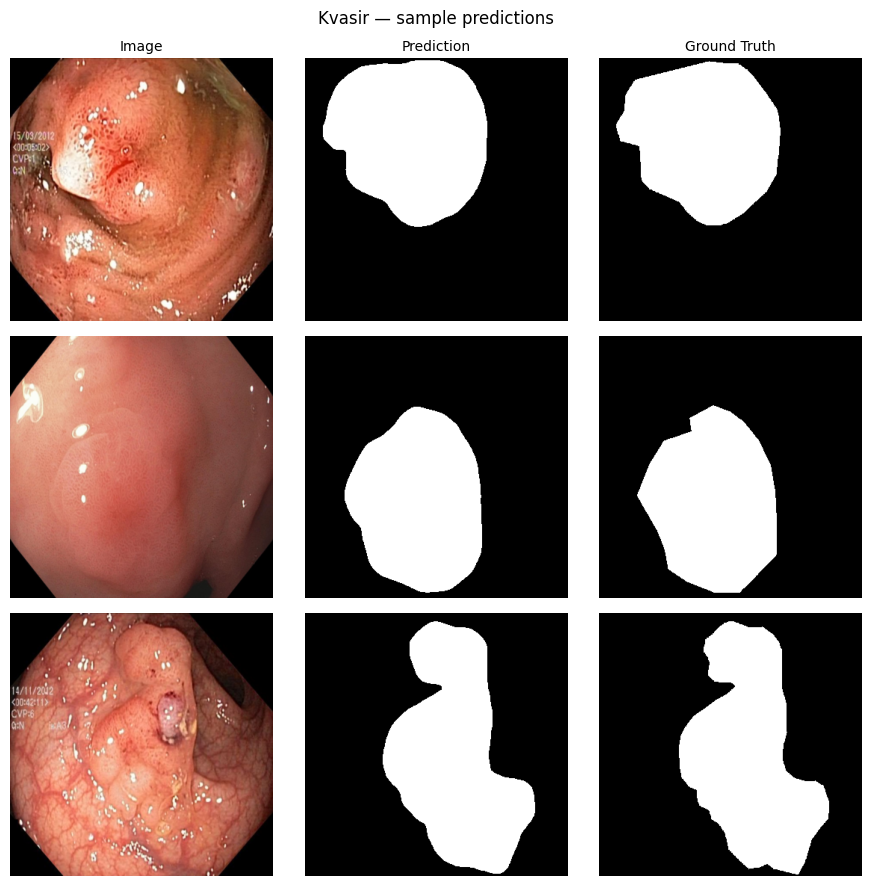

In [17]:
import matplotlib.pyplot as plt

EPS = 1.0  # Laplace smoothing, matches official measure/metric.py convention
os.makedirs("/kaggle/working/predictions", exist_ok=True)

results = {}
viz_samples = {}

# Image un-normalization constants for visualization
mean_ = np.array([0.485, 0.456, 0.406])
std_ = np.array([0.229, 0.224, 0.225])

model.eval()
# Inside the evaluation loop cell
with torch.no_grad():
    for name, loader in loaders.items():
        dices, ious = [], []
        for i, (image, gt, fname) in enumerate(loader):
            image = image.to(DEVICE)
            out = model(image)
            
            # SEPNet outputs a list/tuple of predictions; the main prediction is typically index 0 or -1
            pred = out[0] if isinstance(out, (tuple, list)) else out
            
            # Resize prediction map to match ground truth target dimensions
            pred = F.interpolate(pred, size=gt.shape[-2:], mode="bilinear", align_corners=False)
            pred = torch.sigmoid(pred).squeeze().cpu().numpy()
            
            # Ground truth and prediction thresholding
            pred_binary = (pred > 0.5).astype(np.float64)
            gt_np = (gt.squeeze().numpy() > 0.5).astype(np.float64)
            
            # Metrics computation
            intersection = (pred_binary * gt_np).sum()
            total_area = pred_binary.sum() + gt_np.sum()
            
            dice = (2.0 * intersection) / (total_area + 1e-8)
            iou = intersection / (total_area - intersection + 1e-8)
            
            dices.append(dice)
            ious.append(iou)
            
            if i < 3:
                viz_samples.setdefault(name, []).append((image[0].cpu(), pred_binary, gt_np, fname[0]))
                cv2.imwrite(f"/kaggle/working/predictions/{name}_{fname[0]}.png", (pred_binary * 255).astype(np.uint8))
                
        results[name] = {"mDice": float(np.mean(dices)), "mIoU": float(np.mean(ious)), "n": len(dices)}
        print(f"[{name}] n={len(dices):4d} | mDice={np.mean(dices):.4f} | mIoU={np.mean(ious):.4f}")
print("\n=== Summary ===")
for name, r in results.items():
    print(f"{name:12s} | N={r['n']:4d} | mDice={r['mDice']:.4f} | mIoU={r['mIoU']:.4f}")

# Visualization section
for name, samples in viz_samples.items():
    fig, axes = plt.subplots(len(samples), 3, figsize=(9, 3 * len(samples)))
    if len(samples) == 1:
        axes = axes[None, :]
    for row, (img_t, pred, gt_np, fname) in enumerate(samples):
        img_np = np.clip(img_t.permute(1, 2, 0).numpy() * std_ + mean_, 0, 1)
        for col, (arr, title, cmap) in enumerate([(img_np, "Image", None), (pred, "Prediction", "gray"), (gt_np, "Ground Truth", "gray")]):
            axes[row, col].imshow(arr, cmap=cmap)
            axes[row, col].set_title(f"{title}" if row == 0 else "", fontsize=10)
            axes[row, col].axis("off")
    fig.suptitle(f"{name} — sample predictions")
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/{name}_samples.png", dpi=120)
    plt.show()